Baza danych (uruchom RAZ)

In [17]:
import pandas as pd
import sqlite3
import os

# 1. Wczytaj CSV
df_raw = pd.read_csv("../data/raw/Sample - Superstore.csv", encoding='latin-1')

# 2. Wyczyść nazwy kolumn
df_raw.columns = (df_raw.columns
                  .str.lower()
                  .str.strip()
                  .str.replace(" ", "_")
                  .str.replace("-", "_"))

df_raw['order_date'] = pd.to_datetime(df_raw['order_date']).dt.strftime('%Y-%m-%d')
df_raw['ship_date']  = pd.to_datetime(df_raw['ship_date']).dt.strftime('%Y-%m-%d')

print("Kolumny:", df_raw.columns.tolist())
print("Shape:", df_raw.shape)

# 3. Zapisz do SQLite
os.makedirs("../data/processed", exist_ok=True)
conn = sqlite3.connect("../data/processed/sales.db")  # <-- NOWY PLIK .db
df_raw.to_sql("orders", conn, if_exists="replace", index=False)
conn.close()

print("Baza gotowa: ../data/processed/sales.db")

Kolumny: ['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']
Shape: (9994, 21)
Baza gotowa: ../data/processed/sales.db


Imports + baza

In [18]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

conn = sqlite3.connect("../data/processed/sales.db")
df = pd.read_sql("SELECT * FROM orders", conn)
print(f"Rows: {len(df)} | Columns: {df.shape[1]}")
df.head()

Rows: 9994 | Columns: 21


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Data types + nulls

In [19]:
print("--- Dtypes ---")
print(df.dtypes)
print("\n--- Nulls ---")
print(df.isnull().sum())

--- Dtypes ---
row_id             int64
order_id             str
order_date           str
ship_date            str
ship_mode            str
customer_id          str
customer_name        str
segment              str
country              str
city                 str
state                str
postal_code        int64
region               str
product_id           str
category             str
sub_category         str
product_name         str
sales            float64
quantity           int64
discount         float64
profit           float64
dtype: object

--- Nulls ---
row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub_category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64


Kolumny dat

In [20]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date']  = pd.to_datetime(df['ship_date'])

# Pomocnicze kolumny
df['year']  = df['order_date'].dt.year
df['month'] = df['order_date'].dt.to_period('M').astype(str)

print("Daty naprawione")
print(df[['order_date','ship_date','year','month']].head())

Daty naprawione
  order_date  ship_date  year    month
0 2016-11-08 2016-11-11  2016  2016-11
1 2016-11-08 2016-11-11  2016  2016-11
2 2016-06-12 2016-06-16  2016  2016-06
3 2015-10-11 2015-10-18  2015  2015-10
4 2015-10-11 2015-10-18  2015  2015-10


In [21]:
df[['sales','quantity','discount','profit']].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
sales,9994.0,229.86,623.25,0.44,17.28,54.49,209.94,22638.48
quantity,9994.0,3.79,2.23,1.00,2.00,3.00,5.00,14.00
discount,9994.0,0.16,0.21,0.00,0.00,0.20,0.20,0.80
profit,9994.0,28.66,234.26,-6599.98,1.73,8.67,29.36,8399.98


Sales i Profit

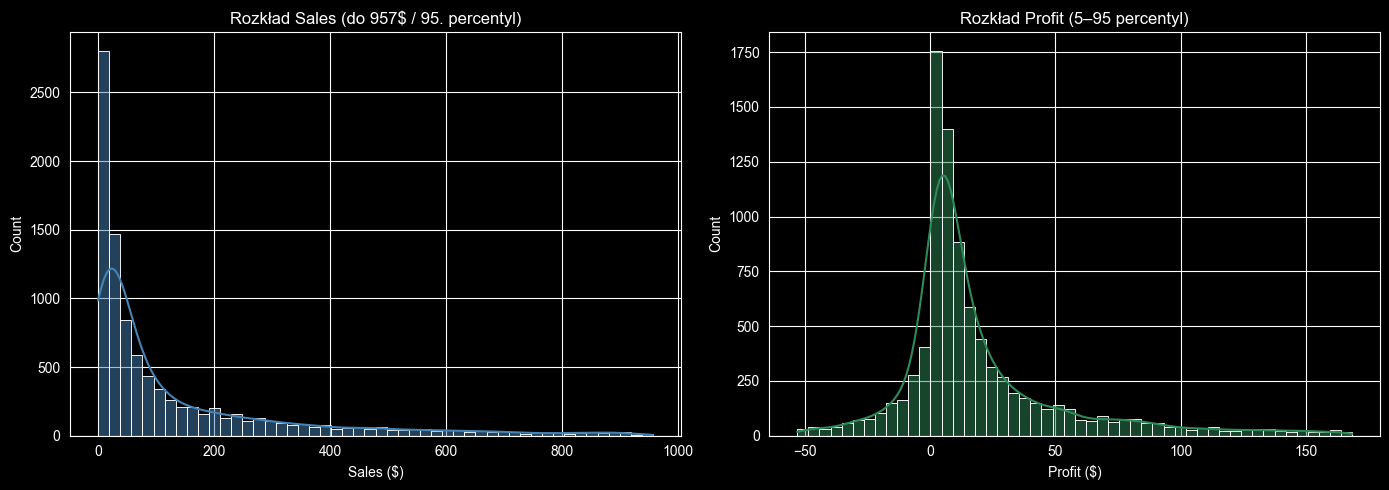

In [22]:
sales_cap  = df['sales'].quantile(0.95)   # ucinamy top 5%
profit_low = df['profit'].quantile(0.05)
profit_cap = df['profit'].quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[df['sales'] <= sales_cap]['sales'],
             bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f"Rozkład Sales (do {sales_cap:.0f}$ / 95. percentyl)")
axes[0].set_xlabel("Sales ($)")

sns.histplot(df[(df['profit'] >= profit_low) & (df['profit'] <= profit_cap)]['profit'],
             bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title("Rozkład Profit (5–95 percentyl)")
axes[1].set_xlabel("Profit ($)")

plt.tight_layout()
plt.show()

Outlinery

In [23]:
print(f"Sales  — max: ${df['sales'].max():,.0f} | 95pc: ${sales_cap:,.0f}")
print(f"Profit — min: ${df['profit'].min():,.0f} | max: ${df['profit'].max():,.0f}")

Sales  — max: $22,638 | 95pc: $957
Profit — min: $-6,600 | max: $8,400


Profit per Category

/var/folders/s7/ys8rs8sx06s_jz946dck60hm0000gn/T/ipykernel_39212/2698451615.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='profit', data=df,


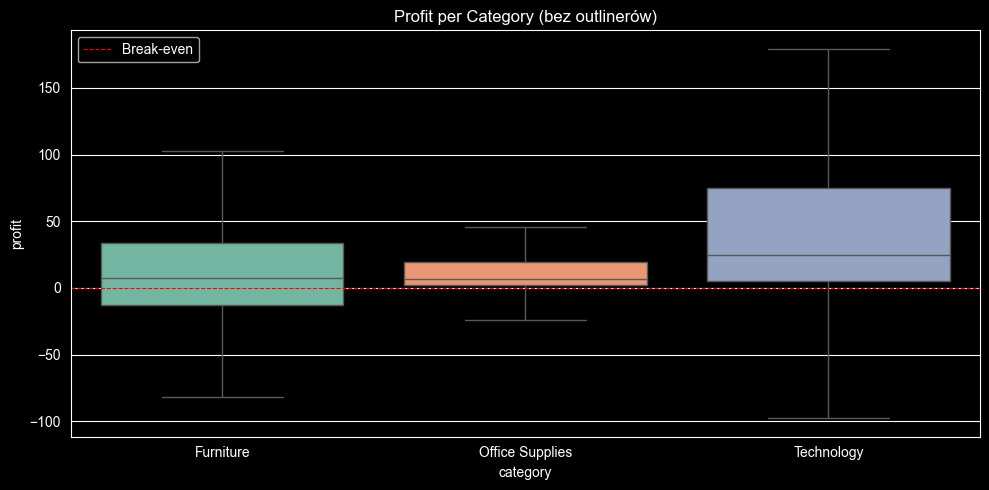

In [24]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='category', y='profit', data=df,
            palette='Set2',
            showfliers=False)   # <-- chowamy outlinery żeby było czytelnie
plt.title("Profit per Category (bez outlinerów)")
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Break-even')
plt.legend()
plt.tight_layout()
plt.savefig("../data/processed/eda_boxplot_category.png", dpi=150)
plt.show()

- Furniture    → ryzykowna, często sprzedajesz poniżej progu rentowności
- Office Supp. → stabilna, pewny ale mały zysk
- Technology   → najlepszy profit, ale duża zmienność

Korelacja

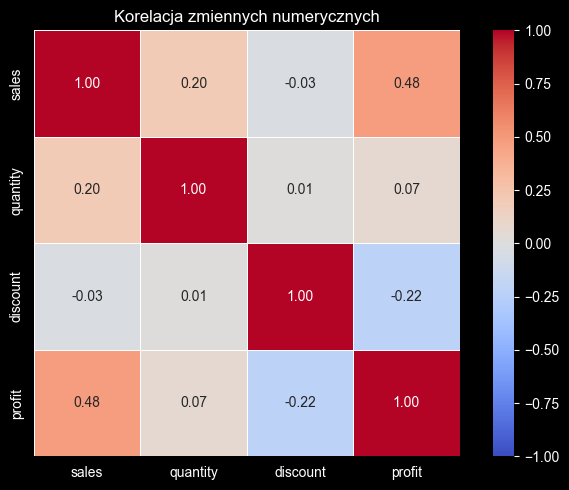

In [25]:
corr = df[['sales', 'quantity', 'discount', 'profit']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f",
            cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=0.5)
plt.title("Korelacja zmiennych numerycznych")
plt.tight_layout()
plt.savefig("../data/processed/eda_correlation.png", dpi=150)
plt.show()

- discount ↔ sales  = -0.03  → rabaty nie zwiększają sprzedaży
- discount ↔ profit = -0.22  → im większy rabat tym mniejszy profit

Wniosek: Polityka rabatowa jest nieefektywna. Firma traci marżę bez wzrostu wolumenu

Monthly Sales vs Profit trend

In [26]:
monthly = (df.groupby('month')[['sales', 'profit']]
             .sum()
             .reset_index())

fig = px.line(monthly, x='month', y=['sales', 'profit'],
              title='📅 Monthly Sales vs Profit Trend',
              markers=True,
              color_discrete_map={'sales': '#0077b6', 'profit': '#2ecc71'},
              labels={'value': '$', 'month': 'Miesiąc', 'variable': 'Metryka'})

fig.update_xaxes(tickangle=45)
fig.update_layout(hovermode='x unified')  # hover pokazuje obie linie naraz
fig.show()

Yearly summary

In [27]:
yearly = (df.groupby('year')[['sales', 'profit']]
            .sum()
            .reset_index())

yearly['profit_margin_%'] = (yearly['profit'] / yearly['sales'] * 100).round(2)
print(yearly.to_string(index=False))

 year       sales     profit  profit_margin_%
 2014 484247.4981 49543.9741            10.23
 2015 470532.5090 61618.6037            13.10
 2016 609205.5980 81795.1743            13.43
 2017 733215.2552 93439.2696            12.74


- Sprzedaż rośnie ~15% rok do roku (2014→2017)
-  Marża zysku spada w 2017 mimo rekordowej sprzedaży
-️  Wyraźna sezonowość — Q4 generuje nieproporcjonalnie duże przychody
- Hipoteza: agresywne rabaty w Q4 napędzają wolumen kosztem marży

Zamknięcie połączenia

In [28]:
conn.close()
print("Połączenie zamknięte")

Połączenie zamknięte
